# 📊 1. Predicción de Probabilidades y Curva ROC


Sin Habilidad: ROC AUC=0.500
Regresión Logística: ROC AUC=0.903


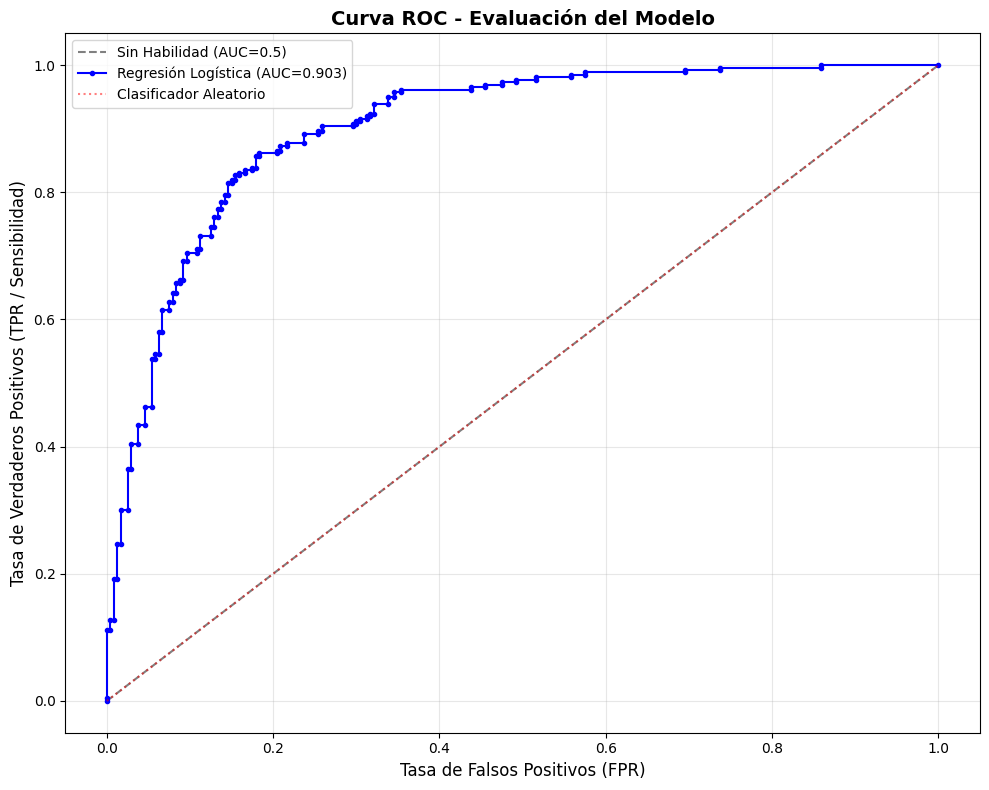

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Generar conjunto de datos de clasificación binaria
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)

# 2. Dividir en entrenamiento y prueba
trainX, testX, trainy, testy = train_test_split(X, y, test_size=0.5, random_state=2)

# 3. Predicción "sin habilidad" (clase mayoritaria siempre 0)
ns_probs = [0 for _ in range(len(testy))]

# 4. Entrenar modelo de Regresión Logística
model = LogisticRegression(solver='lbfgs')
model.fit(trainX, trainy)

# 5. Predecir probabilidades para la clase positiva
lr_probs = model.predict_proba(testX)[:, 1]

# 6. Calcular puntuaciones AUC-ROC
ns_auc = roc_auc_score(testy, ns_probs)
lr_auc = roc_auc_score(testy, lr_probs)
print('Sin Habilidad: ROC AUC=%.3f' % ns_auc)
print('Regresión Logística: ROC AUC=%.3f' % lr_auc)

# 7. Calcular curvas ROC
ns_fpr, ns_tpr, _ = roc_curve(testy, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(testy, lr_probs)

# 8. Graficar curva ROC
plt.figure(figsize=(10, 8))
plt.plot(ns_fpr, ns_tpr, linestyle='--', color='gray', label='Sin Habilidad (AUC=0.5)')
plt.plot(lr_fpr, lr_tpr, marker='.', color='blue', label='Regresión Logística (AUC=%.3f)' % lr_auc)

# Configuración del gráfico
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Sensibilidad)', fontsize=12)
plt.title('Curva ROC - Evaluación del Modelo', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

# Línea de referencia para clasificador aleatorio
plt.plot([0, 1], [0, 1], color='red', linestyle=':', alpha=0.5, label='Clasificador Aleatorio')

plt.legend()
plt.tight_layout()
plt.show()

# 📈 2. Curvas Precision-Recall para Datos Desbalanceados


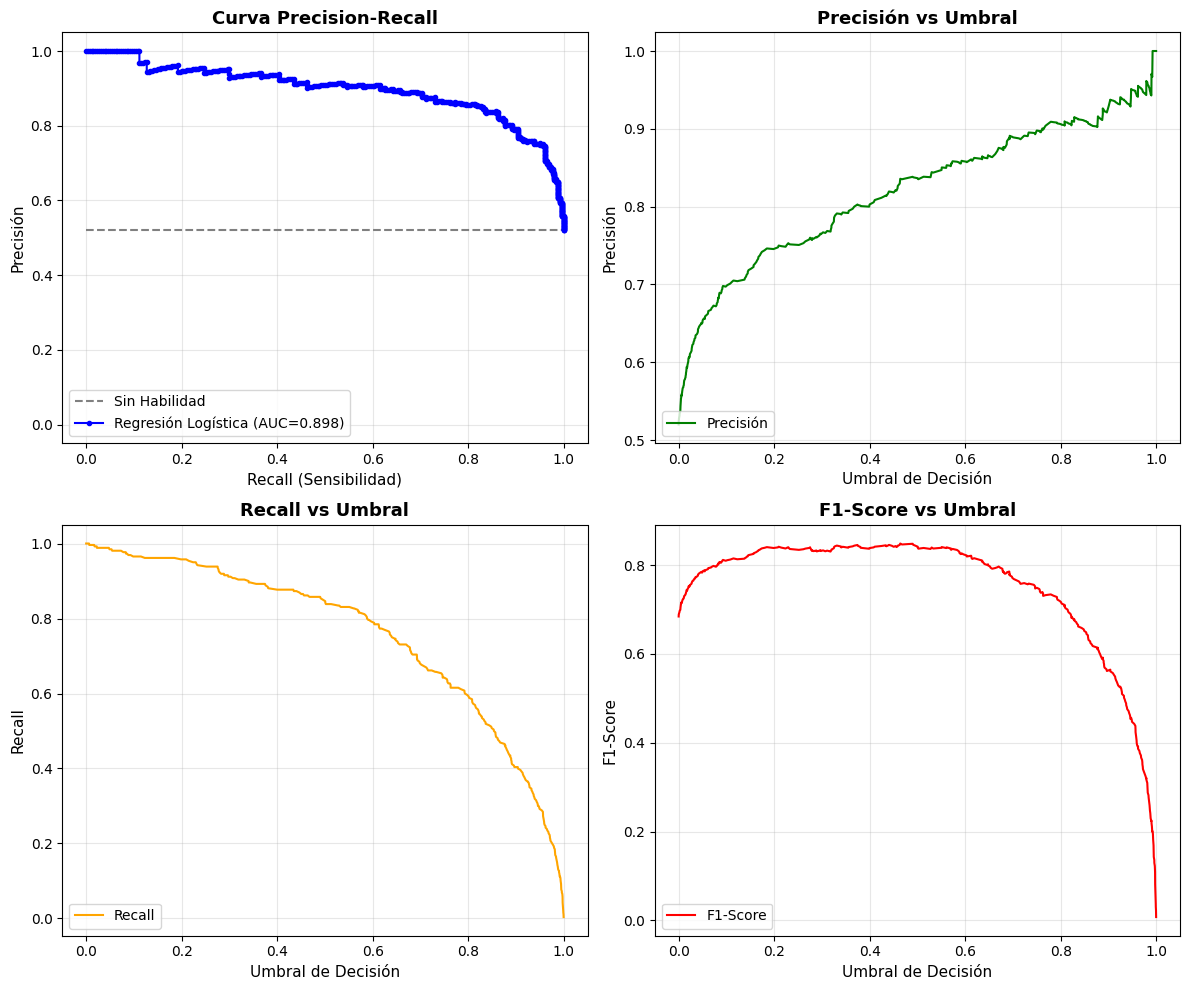


Umbral Óptimo: 0.464
Precisión en umbral óptimo: 0.836
Recall en umbral óptimo: 0.862
F1-Score máximo: 0.848


In [2]:
from sklearn.metrics import precision_recall_curve, auc
import numpy as np

# 1. Calcular precisión y recall para diferentes umbrales
lr_precision, lr_recall, thresholds = precision_recall_curve(testy, lr_probs)

# 2. Calcular AUC (área bajo la curva Precision-Recall)
lr_auc = auc(lr_recall, lr_precision)

# 3. Calcular línea base "sin habilidad"
# En datos balanceados, la línea base es la proporción de positivos
no_skill = len(testy[testy==1]) / len(testy)

# 4. Graficar curva Precision-Recall
plt.figure(figsize=(12, 10))

# Subgráfico 1: Curva Precision-Recall
plt.subplot(2, 2, 1)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='gray', label='Sin Habilidad')
plt.plot(lr_recall, lr_precision, marker='.', color='blue', label='Regresión Logística (AUC=%.3f)' % lr_auc)
plt.xlabel('Recall (Sensibilidad)', fontsize=11)
plt.ylabel('Precisión', fontsize=11)
plt.title('Curva Precision-Recall', fontsize=13, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])

# Subgráfico 2: Precisión vs Umbral
plt.subplot(2, 2, 2)
plt.plot(thresholds, lr_precision[:-1], color='green', label='Precisión')
plt.xlabel('Umbral de Decisión', fontsize=11)
plt.ylabel('Precisión', fontsize=11)
plt.title('Precisión vs Umbral', fontsize=13, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)

# Subgráfico 3: Recall vs Umbral
plt.subplot(2, 2, 3)
plt.plot(thresholds, lr_recall[:-1], color='orange', label='Recall')
plt.xlabel('Umbral de Decisión', fontsize=11)
plt.ylabel('Recall', fontsize=11)
plt.title('Recall vs Umbral', fontsize=13, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)

# Subgráfico 4: F1-Score vs Umbral
plt.subplot(2, 2, 4)
f1_scores = 2 * (lr_precision[:-1] * lr_recall[:-1]) / (lr_precision[:-1] + lr_recall[:-1] + 1e-10)
plt.plot(thresholds, f1_scores, color='red', label='F1-Score')
plt.xlabel('Umbral de Decisión', fontsize=11)
plt.ylabel('F1-Score', fontsize=11)
plt.title('F1-Score vs Umbral', fontsize=13, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Encontrar el umbral óptimo basado en F1-Score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_precision = lr_precision[optimal_idx]
optimal_recall = lr_recall[optimal_idx]

print(f"\nUmbral Óptimo: {optimal_threshold:.3f}")
print(f"Precisión en umbral óptimo: {optimal_precision:.3f}")
print(f"Recall en umbral óptimo: {optimal_recall:.3f}")
print(f"F1-Score máximo: {f1_scores[optimal_idx]:.3f}")

# 🎯 3. Comparación Completa: ROC vs Precision-Recall en Diferentes Escenarios


DATOS BALANCEADOS (50/50)


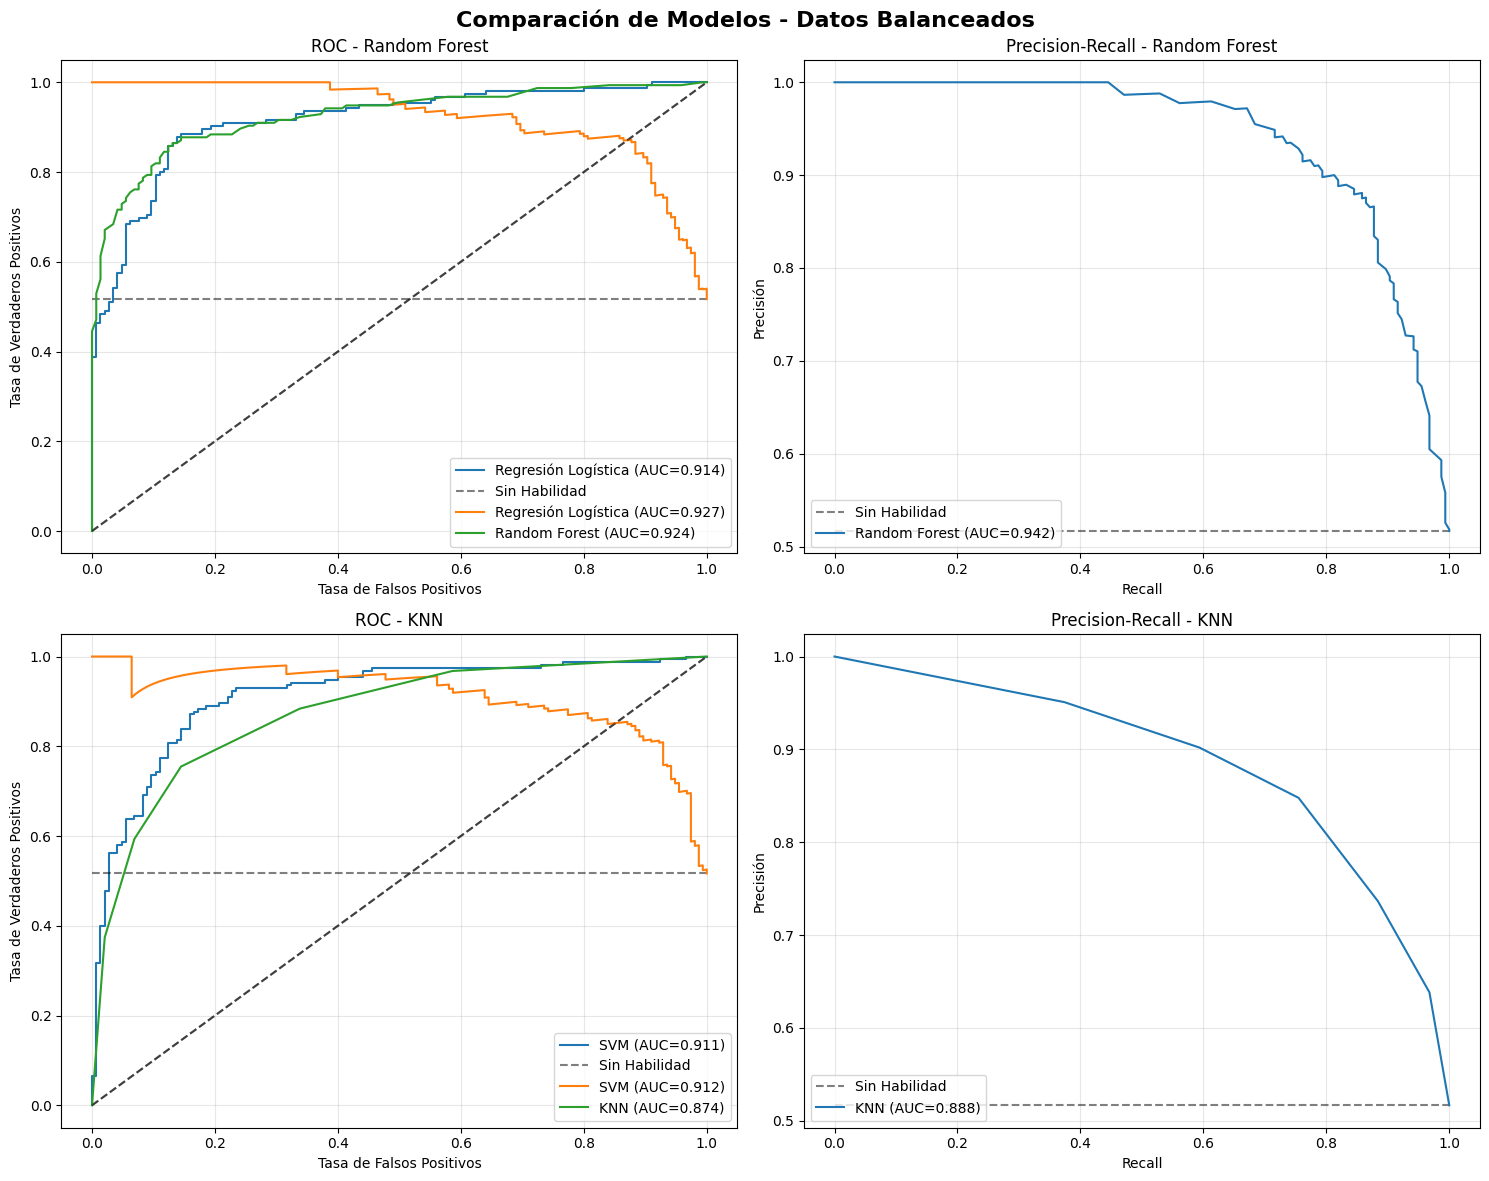


Resultados Comparativos - Datos Balanceados:
             Modelo ROC AUC PR AUC Accuracy F1-Score
Regresión Logística   0.914  0.927    0.850    0.850
      Random Forest   0.924  0.942    0.857    0.856
                SVM   0.911  0.912    0.847    0.850
                KNN   0.874  0.888    0.803    0.799


DATOS DESBALANCEADOS (90/10)


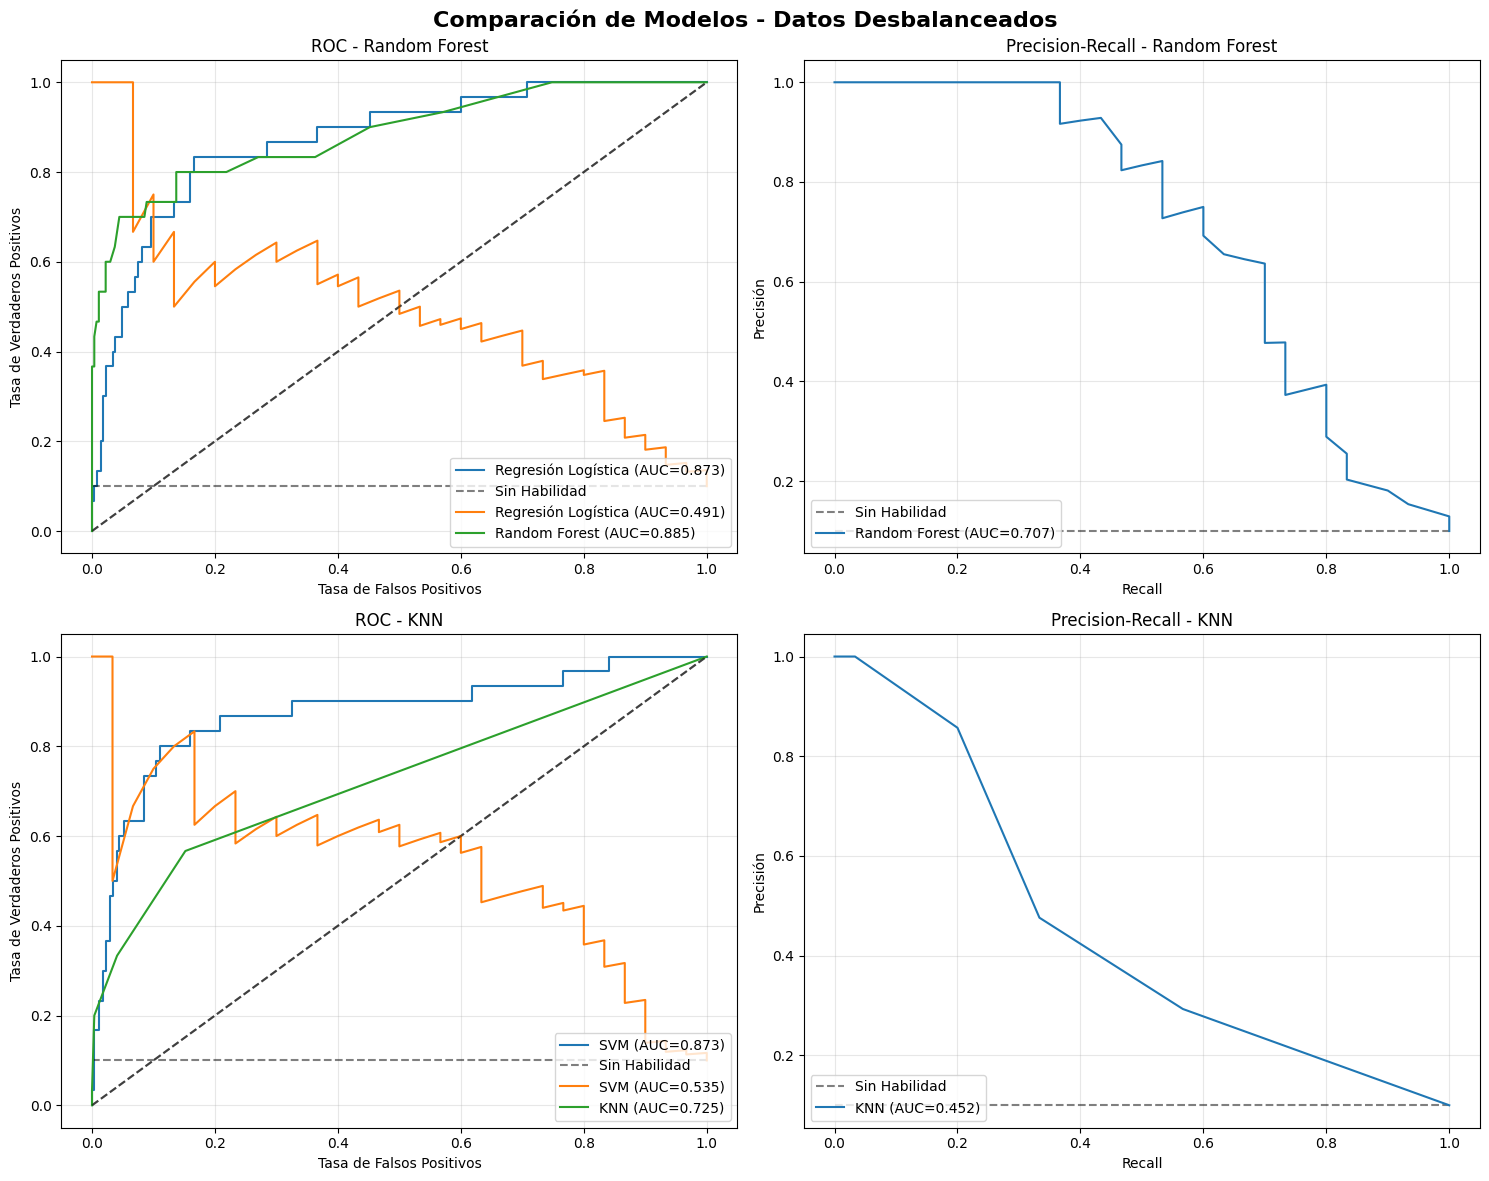


Resultados Comparativos - Datos Desbalanceados:
             Modelo ROC AUC PR AUC Accuracy F1-Score
Regresión Logística   0.873  0.491    0.910    0.471
      Random Forest   0.885  0.707    0.940    0.625
                SVM   0.873  0.535    0.913    0.458
                KNN   0.725  0.452    0.917    0.324


In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc,
    accuracy_score,
    f1_score
)

# Crear datos balanceados y desbalanceados
X_balanced, y_balanced = make_classification(
    n_samples=1000, n_classes=2, weights=[0.5, 0.5], random_state=42
)

X_imbalanced, y_imbalanced = make_classification(
    n_samples=1000, n_classes=2, weights=[0.9, 0.1], random_state=42
)

# Dividir ambos conjuntos
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_balanced, y_balanced, test_size=0.3, random_state=42
)
Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_imbalanced, y_imbalanced, test_size=0.3, random_state=42
)

# Definir modelos a comparar
models = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier()
}

# Función para evaluar y graficar modelos
def evaluate_and_plot_models(X_train, X_test, y_train, y_test, title_suffix):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for idx, (name, model) in enumerate(models.items()):
        if idx >= 4:
            break

        # Entrenar modelo
        model.fit(X_train, y_train)
        y_probs = model.predict_proba(X_test)[:, 1]

        # Calcular métricas ROC
        fpr, tpr, _ = roc_curve(y_test, y_probs)
        roc_auc = roc_auc_score(y_test, y_probs)

        # Calcular métricas Precision-Recall
        precision, recall, _ = precision_recall_curve(y_test, y_probs)
        pr_auc = auc(recall, precision)

        # Gráfico ROC
        ax_roc = axes[0] if idx == 0 else axes[2] if idx == 2 else axes[idx-1]
        ax_roc.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')
        ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
        ax_roc.set_xlabel('Tasa de Falsos Positivos')
        ax_roc.set_ylabel('Tasa de Verdaderos Positivos')
        ax_roc.set_title(f'ROC - {name}')
        ax_roc.legend(loc='lower right')
        ax_roc.grid(True, alpha=0.3)

        # Gráfico Precision-Recall
        ax_pr = axes[1] if idx == 1 else axes[3] if idx == 3 else axes[idx]
        no_skill = len(y_test[y_test==1]) / len(y_test)
        ax_pr.plot([0, 1], [no_skill, no_skill], 'k--', alpha=0.5, label='Sin Habilidad')
        ax_pr.plot(recall, precision, label=f'{name} (AUC={pr_auc:.3f})')
        ax_pr.set_xlabel('Recall')
        ax_pr.set_ylabel('Precisión')
        ax_pr.set_title(f'Precision-Recall - {name}')
        ax_pr.legend(loc='lower left')
        ax_pr.grid(True, alpha=0.3)

    plt.suptitle(f'Comparación de Modelos - {title_suffix}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Tabla comparativa de resultados
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_probs = model.predict_proba(X_test)[:, 1]
        y_pred = (y_probs > 0.5).astype(int)

        roc_auc = roc_auc_score(y_test, y_probs)
        precision, recall, _ = precision_recall_curve(y_test, y_probs)
        pr_auc = auc(recall, precision)

        results.append({
            'Modelo': name,
            'ROC AUC': f'{roc_auc:.3f}',
            'PR AUC': f'{pr_auc:.3f}',
            'Accuracy': f'{accuracy_score(y_test, y_pred):.3f}',
            'F1-Score': f'{f1_score(y_test, y_pred):.3f}'
        })

    results_df = pd.DataFrame(results)
    print(f"\nResultados Comparativos - {title_suffix}:")
    print("=" * 70)
    print(results_df.to_string(index=False))
    print("=" * 70)

# Evaluar en datos balanceados
print("DATOS BALANCEADOS (50/50)")
print("=" * 50)
evaluate_and_plot_models(Xb_train, Xb_test, yb_train, yb_test, "Datos Balanceados")

# Evaluar en datos desbalanceados
print("\n\nDATOS DESBALANCEADOS (90/10)")
print("=" * 50)
evaluate_and_plot_models(Xi_train, Xi_test, yi_train, yi_test, "Datos Desbalanceados")

# 📊 4. Análisis Detallado con Múltiples Métricas


ANÁLISIS COMPLETO DE MODELOS

Analizando Regresión Logística...


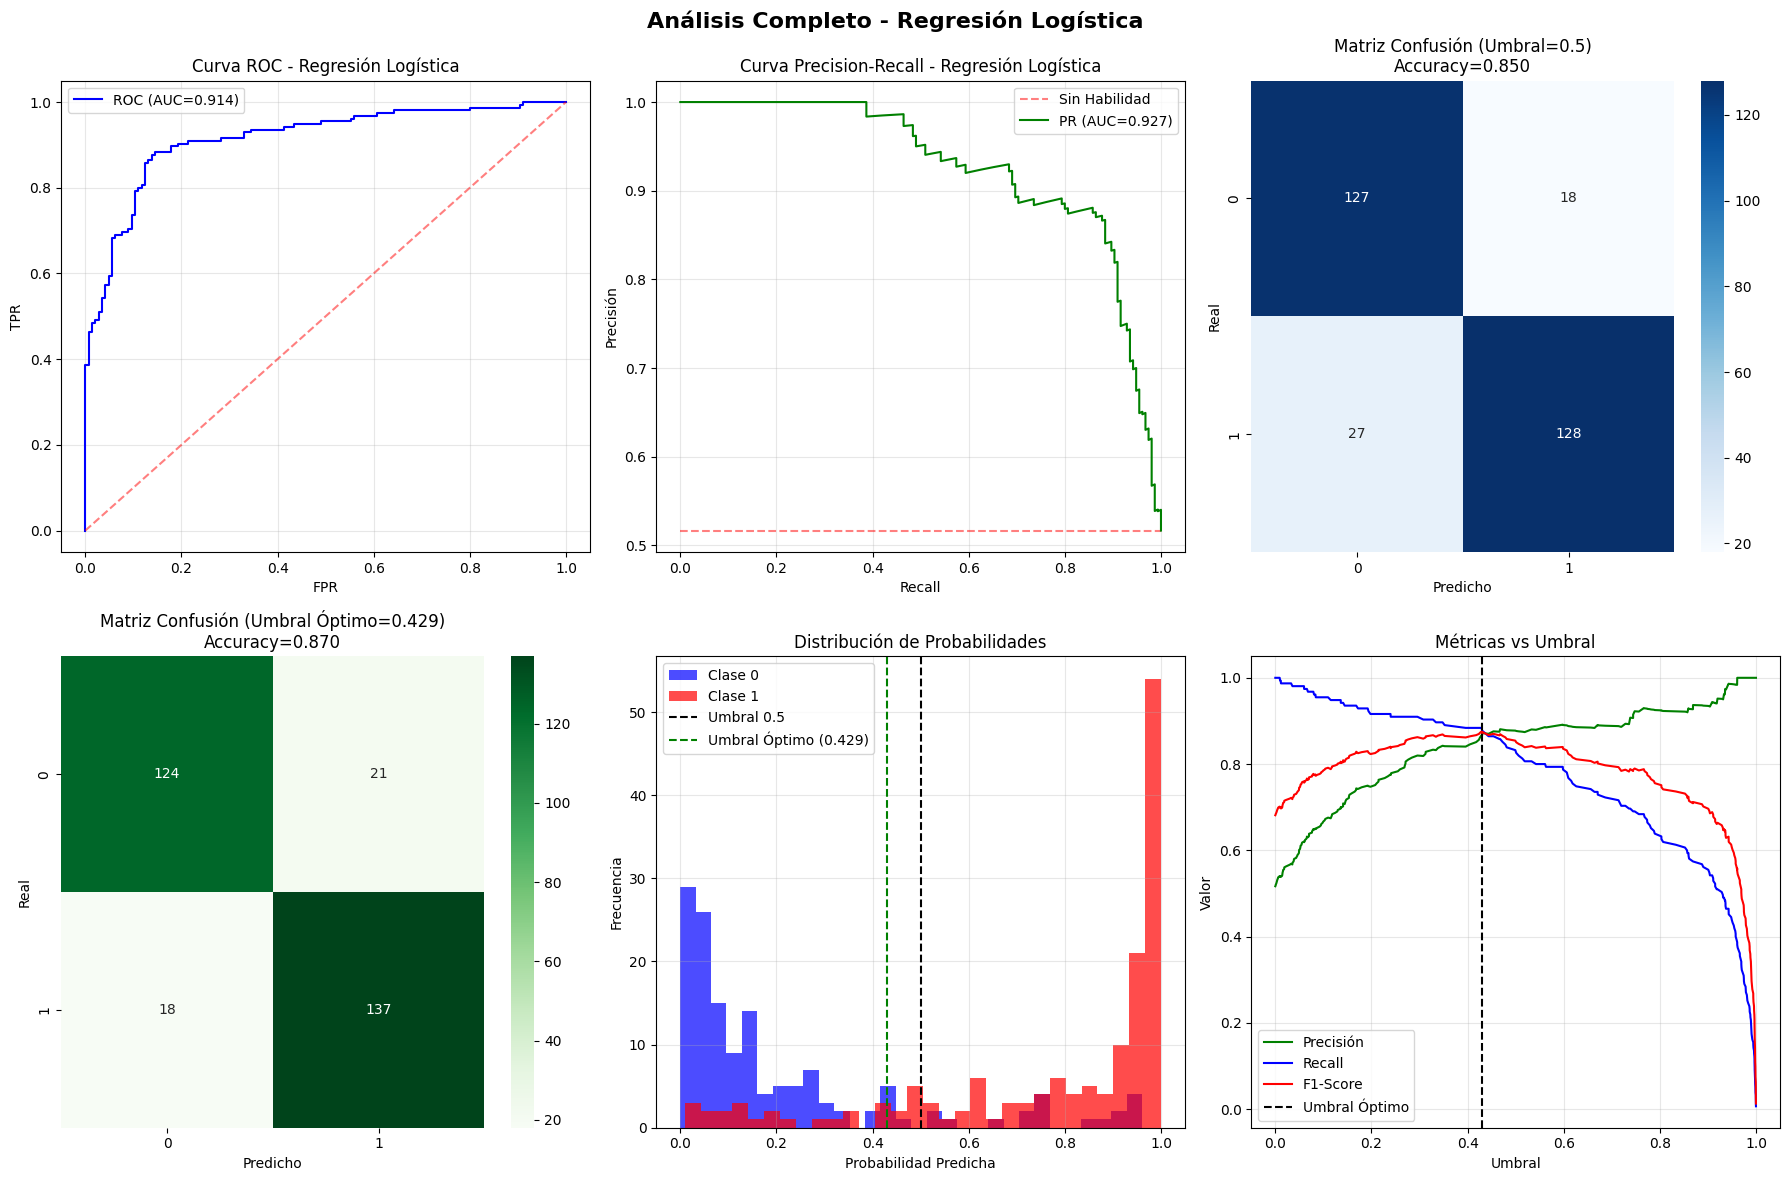


REPORTE DE CLASIFICACIÓN - Regresión Logística

Métricas Principales:
  ROC AUC: 0.914
  PR AUC: 0.927
  Umbral Óptimo: 0.429
  F1 Óptimo: 0.875
  Precisión Óptima: 0.867
  Recall Óptimo: 0.884

Reporte Clasificación (Umbral 0.5):
              precision    recall  f1-score   support

     Clase 0       0.82      0.88      0.85       145
     Clase 1       0.88      0.83      0.85       155

    accuracy                           0.85       300
   macro avg       0.85      0.85      0.85       300
weighted avg       0.85      0.85      0.85       300


Reporte Clasificación (Umbral Óptimo 0.429):
              precision    recall  f1-score   support

     Clase 0       0.87      0.86      0.86       145
     Clase 1       0.87      0.88      0.88       155

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300


Analizando Random Forest...


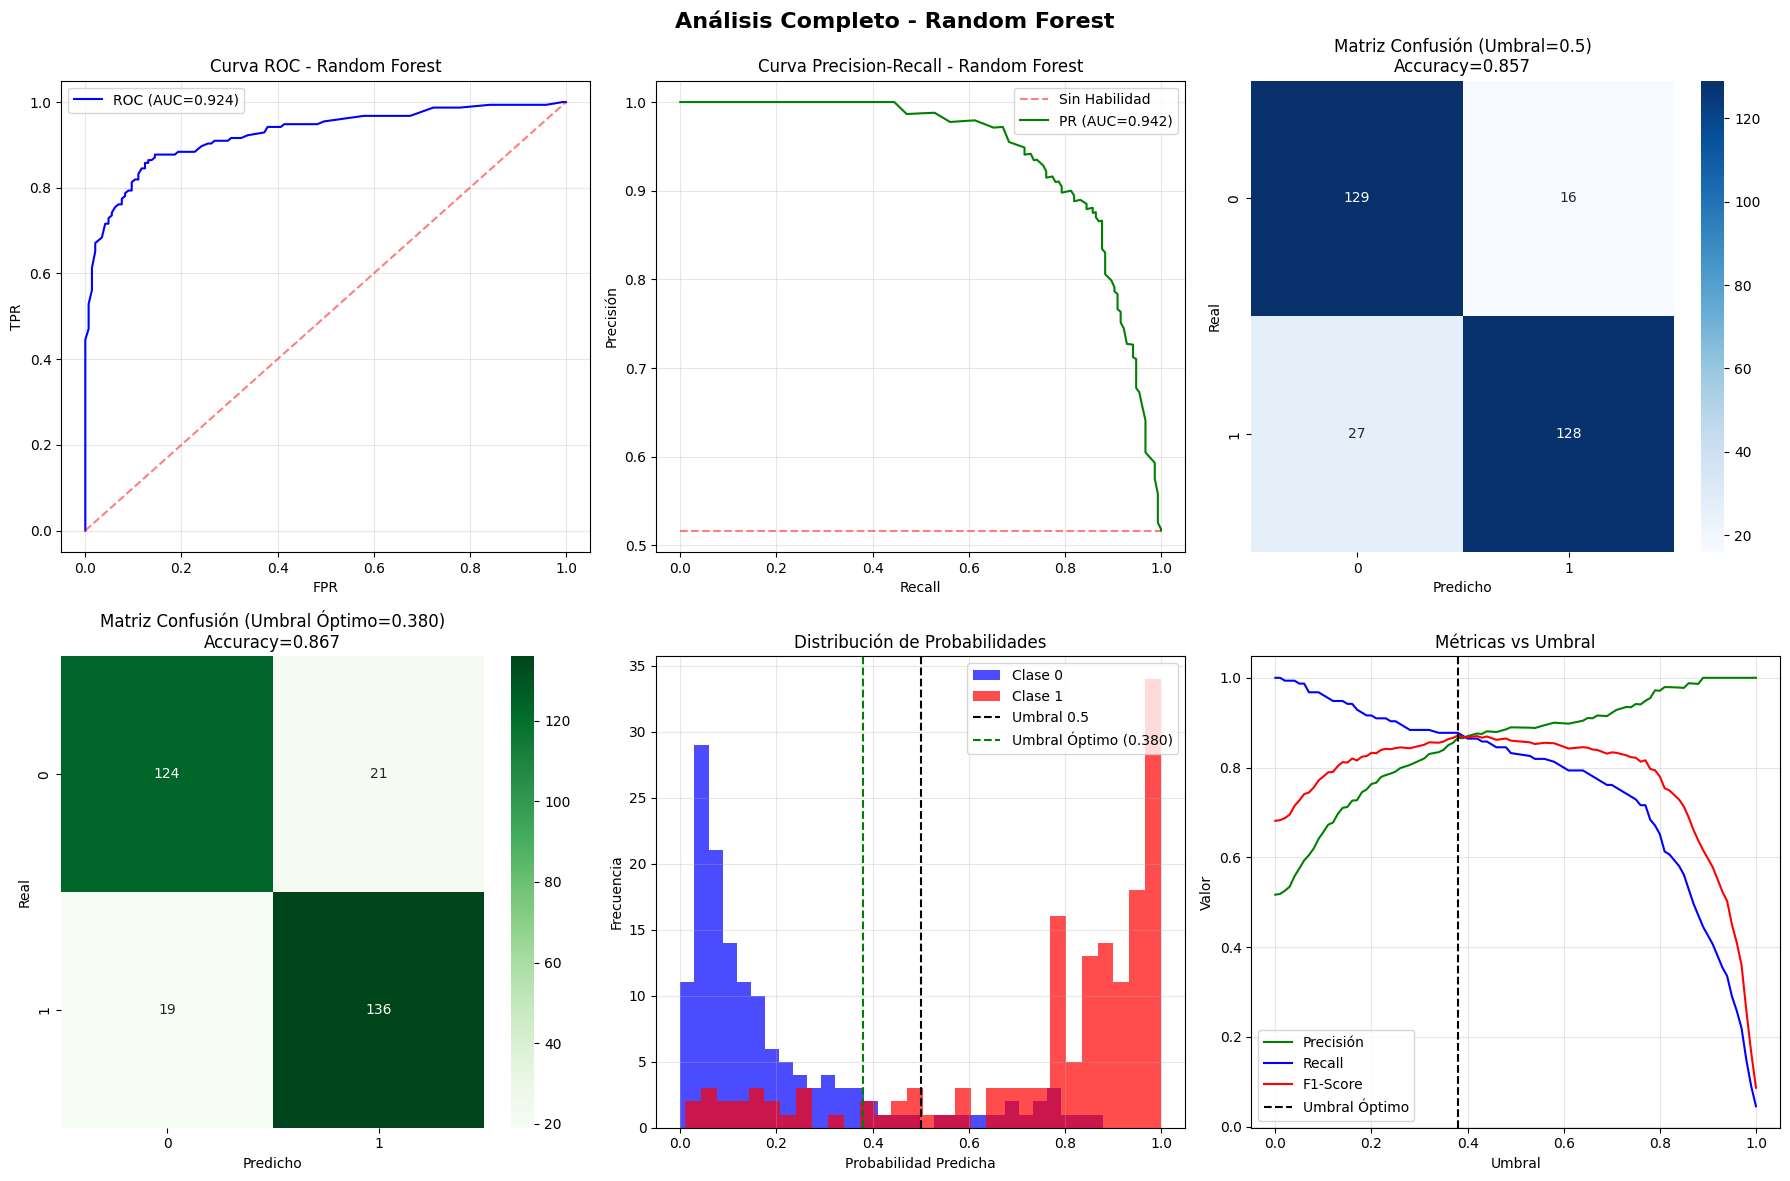


REPORTE DE CLASIFICACIÓN - Random Forest

Métricas Principales:
  ROC AUC: 0.924
  PR AUC: 0.942
  Umbral Óptimo: 0.380
  F1 Óptimo: 0.872
  Precisión Óptima: 0.866
  Recall Óptimo: 0.877

Reporte Clasificación (Umbral 0.5):
              precision    recall  f1-score   support

     Clase 0       0.83      0.89      0.86       145
     Clase 1       0.89      0.83      0.86       155

    accuracy                           0.86       300
   macro avg       0.86      0.86      0.86       300
weighted avg       0.86      0.86      0.86       300


Reporte Clasificación (Umbral Óptimo 0.380):
              precision    recall  f1-score   support

     Clase 0       0.87      0.86      0.86       145
     Clase 1       0.87      0.88      0.87       155

    accuracy                           0.87       300
   macro avg       0.87      0.87      0.87       300
weighted avg       0.87      0.87      0.87       300


Analizando SVM...


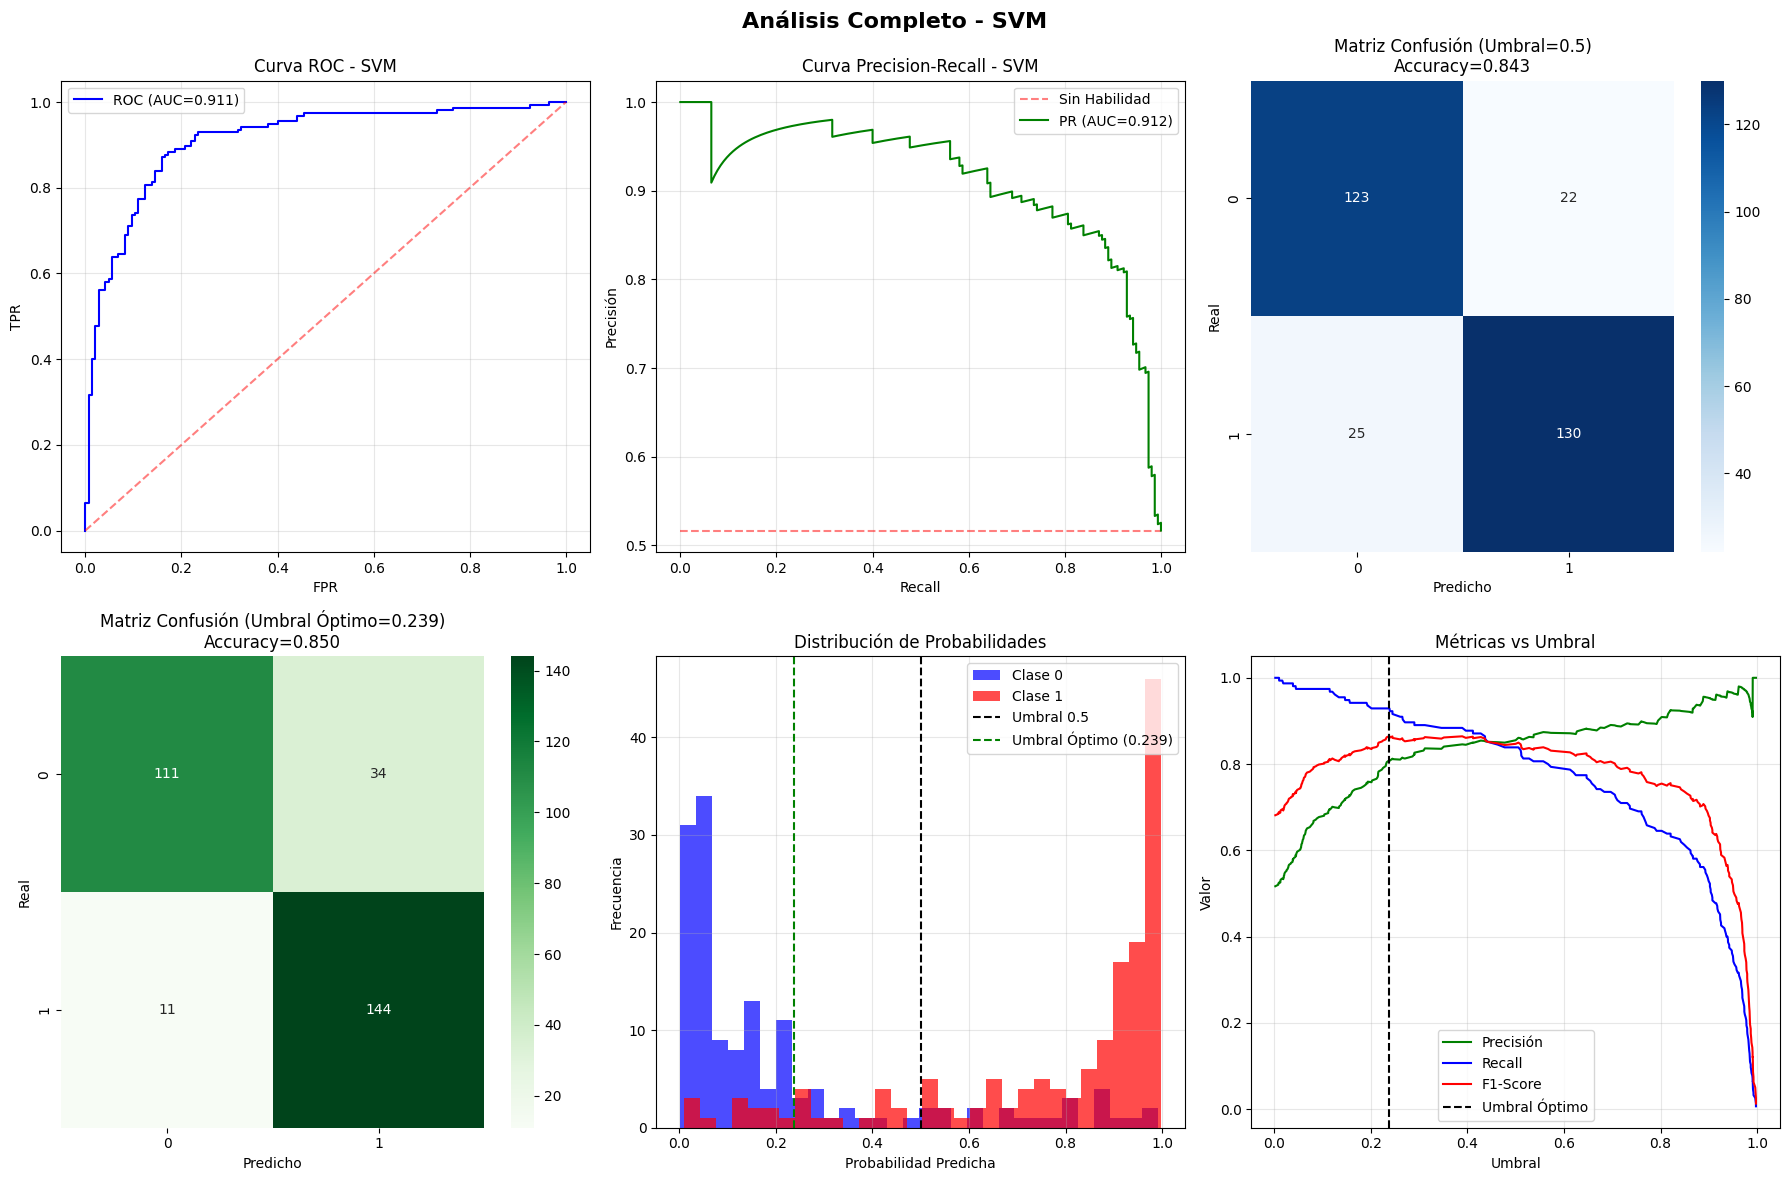


REPORTE DE CLASIFICACIÓN - SVM

Métricas Principales:
  ROC AUC: 0.911
  PR AUC: 0.912
  Umbral Óptimo: 0.239
  F1 Óptimo: 0.865
  Precisión Óptima: 0.809
  Recall Óptimo: 0.929

Reporte Clasificación (Umbral 0.5):
              precision    recall  f1-score   support

     Clase 0       0.83      0.85      0.84       145
     Clase 1       0.86      0.84      0.85       155

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300


Reporte Clasificación (Umbral Óptimo 0.239):
              precision    recall  f1-score   support

     Clase 0       0.91      0.77      0.83       145
     Clase 1       0.81      0.93      0.86       155

    accuracy                           0.85       300
   macro avg       0.86      0.85      0.85       300
weighted avg       0.86      0.85      0.85       300


RESUMEN COMPARATIVO DE TODOS LOS MODELOS

Métricas de Evaluación:
                 

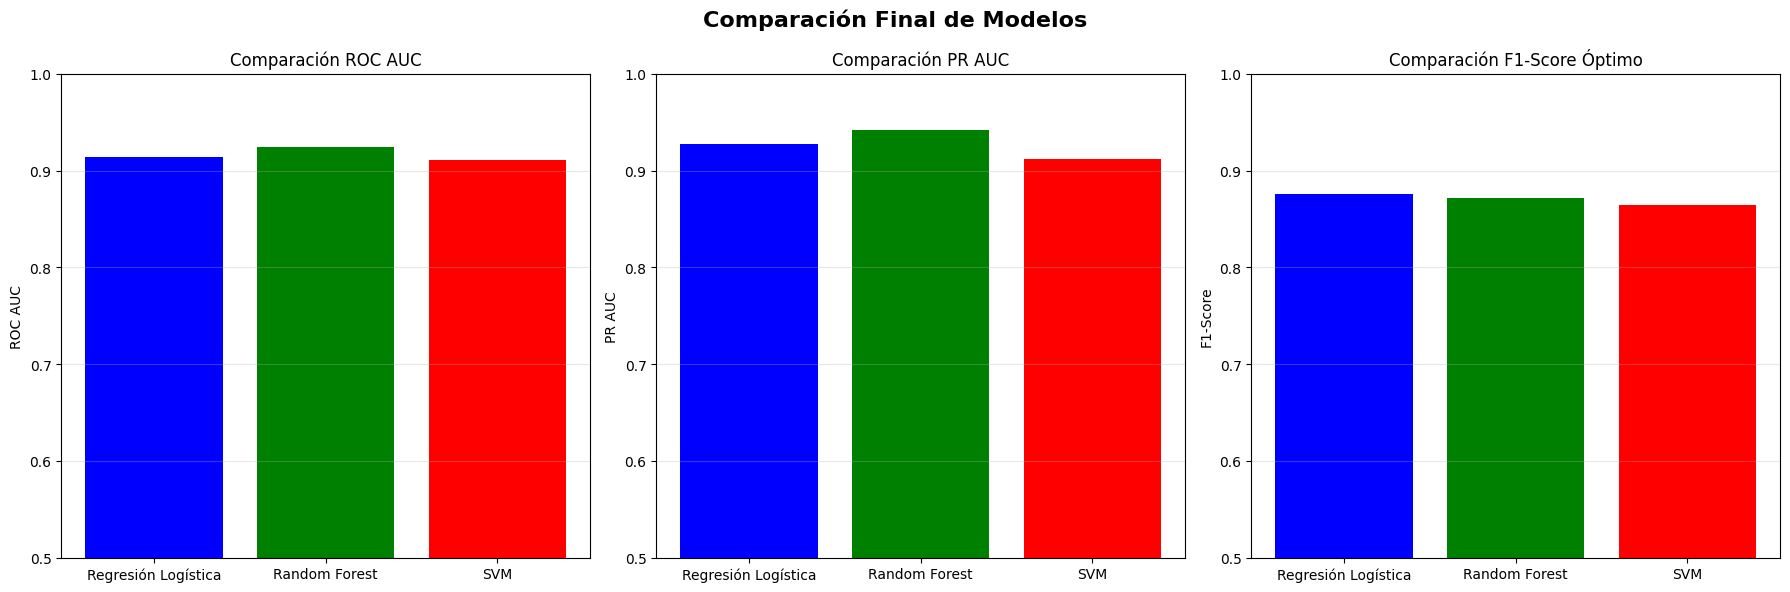

In [5]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Función para análisis completo con umbral óptimo
def comprehensive_model_analysis(model, X_train, X_test, y_train, y_test, model_name):
    # Entrenar modelo
    model.fit(X_train, y_train)
    y_probs = model.predict_proba(X_test)[:, 1]

    # Encontrar umbral óptimo basado en F1-Score
    precision, recall, thresholds = precision_recall_curve(y_test, y_probs)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]

    # Predicciones con umbral óptimo
    y_pred_optimal = (y_probs >= optimal_threshold).astype(int)

    # Predicciones con umbral 0.5
    y_pred_default = (y_probs >= 0.5).astype(int)

    # Calcular métricas
    metrics = {
        'ROC AUC': roc_auc_score(y_test, y_probs),
        'PR AUC': auc(recall, precision),
        'Umbral Óptimo': optimal_threshold,
        'F1 Óptimo': f1_scores[optimal_idx],
        'Precisión Óptima': precision[optimal_idx],
        'Recall Óptimo': recall[optimal_idx]
    }

    # Crear figura con múltiples subgráficos
    fig = plt.figure(figsize=(18, 12))

    # 1. Curva ROC
    ax1 = plt.subplot(2, 3, 1)
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    ax1.plot(fpr, tpr, 'b-', label=f'ROC (AUC={metrics["ROC AUC"]:.3f})')
    ax1.plot([0, 1], [0, 1], 'r--', alpha=0.5)
    ax1.set_xlabel('FPR')
    ax1.set_ylabel('TPR')
    ax1.set_title(f'Curva ROC - {model_name}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Curva Precision-Recall
    ax2 = plt.subplot(2, 3, 2)
    no_skill = len(y_test[y_test==1]) / len(y_test)
    ax2.plot([0, 1], [no_skill, no_skill], 'r--', alpha=0.5, label='Sin Habilidad')
    ax2.plot(recall, precision, 'g-', label=f'PR (AUC={metrics["PR AUC"]:.3f})')
    ax2.set_xlabel('Recall')
    ax2.set_ylabel('Precisión')
    ax2.set_title(f'Curva Precision-Recall - {model_name}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Matriz de Confusión (Umbral 0.5)
    ax3 = plt.subplot(2, 3, 3)
    cm_default = confusion_matrix(y_test, y_pred_default)
    sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues', ax=ax3)
    ax3.set_title(f'Matriz Confusión (Umbral=0.5)\nAccuracy={accuracy_score(y_test, y_pred_default):.3f}')
    ax3.set_ylabel('Real')
    ax3.set_xlabel('Predicho')

    # 4. Matriz de Confusión (Umbral Óptimo)
    ax4 = plt.subplot(2, 3, 4)
    cm_optimal = confusion_matrix(y_test, y_pred_optimal)
    sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Greens', ax=ax4)
    ax4.set_title(f'Matriz Confusión (Umbral Óptimo={optimal_threshold:.3f})\nAccuracy={accuracy_score(y_test, y_pred_optimal):.3f}')
    ax4.set_ylabel('Real')
    ax4.set_xlabel('Predicho')

    # 5. Distribución de Probabilidades
    ax5 = plt.subplot(2, 3, 5)
    ax5.hist(y_probs[y_test==0], bins=30, alpha=0.7, label='Clase 0', color='blue')
    ax5.hist(y_probs[y_test==1], bins=30, alpha=0.7, label='Clase 1', color='red')
    ax5.axvline(x=0.5, color='black', linestyle='--', label='Umbral 0.5')
    ax5.axvline(x=optimal_threshold, color='green', linestyle='--', label=f'Umbral Óptimo ({optimal_threshold:.3f})')
    ax5.set_xlabel('Probabilidad Predicha')
    ax5.set_ylabel('Frecuencia')
    ax5.set_title('Distribución de Probabilidades')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # 6. Métricas por Umbral
    ax6 = plt.subplot(2, 3, 6)
    ax6.plot(thresholds, precision[:-1], 'g-', label='Precisión')
    ax6.plot(thresholds, recall[:-1], 'b-', label='Recall')
    ax6.plot(thresholds, f1_scores, 'r-', label='F1-Score')
    ax6.axvline(x=optimal_threshold, color='black', linestyle='--', label=f'Umbral Óptimo')
    ax6.set_xlabel('Umbral')
    ax6.set_ylabel('Valor')
    ax6.set_title('Métricas vs Umbral')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    plt.suptitle(f'Análisis Completo - {model_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Reporte de clasificación
    print(f"\n{'='*70}")
    print(f"REPORTE DE CLASIFICACIÓN - {model_name}")
    print(f"{'='*70}")
    print(f"\nMétricas Principales:")
    for key, value in metrics.items():
        print(f"  {key}: {value:.3f}")

    print(f"\nReporte Clasificación (Umbral 0.5):")
    print(classification_report(y_test, y_pred_default, target_names=['Clase 0', 'Clase 1']))

    print(f"\nReporte Clasificación (Umbral Óptimo {optimal_threshold:.3f}):")
    print(classification_report(y_test, y_pred_optimal, target_names=['Clase 0', 'Clase 1']))

    return metrics

# Ejecutar análisis para diferentes modelos
print("ANÁLISIS COMPLETO DE MODELOS")
print("="*70)

# Usar datos balanceados para el análisis
models_to_analyze = {
    'Regresión Logística': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

all_metrics = {}
for name, model in models_to_analyze.items():
    print(f"\nAnalizando {name}...")
    metrics = comprehensive_model_analysis(model, Xb_train, Xb_test, yb_train, yb_test, name)
    all_metrics[name] = metrics

# Resumen comparativo
print(f"\n{'='*70}")
print("RESUMEN COMPARATIVO DE TODOS LOS MODELOS")
print(f"{'='*70}")

summary_df = pd.DataFrame(all_metrics).T
print("\nMétricas de Evaluación:")
print(summary_df[['ROC AUC', 'PR AUC', 'F1 Óptimo', 'Umbral Óptimo']])

# Gráfico comparativo final
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Comparación ROC AUC
axes[0].bar(summary_df.index, summary_df['ROC AUC'], color=['blue', 'green', 'red'])
axes[0].set_title('Comparación ROC AUC')
axes[0].set_ylabel('ROC AUC')
axes[0].set_ylim([0.5, 1.0])
axes[0].grid(True, alpha=0.3, axis='y')

# Comparación PR AUC
axes[1].bar(summary_df.index, summary_df['PR AUC'], color=['blue', 'green', 'red'])
axes[1].set_title('Comparación PR AUC')
axes[1].set_ylabel('PR AUC')
axes[1].set_ylim([0.5, 1.0])
axes[1].grid(True, alpha=0.3, axis='y')

# Comparación F1-Score
axes[2].bar(summary_df.index, summary_df['F1 Óptimo'], color=['blue', 'green', 'red'])
axes[2].set_title('Comparación F1-Score Óptimo')
axes[2].set_ylabel('F1-Score')
axes[2].set_ylim([0.5, 1.0])
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparación Final de Modelos', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()